In [11]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


##Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:


# Use the full, exact path to your file
df = pd.read_csv(r"C:\Users\HP\Downloads\Customer Churn.csv")
df


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [14]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Convert 0 and 1 value of senior citizen to yes/no to make it easier to understand

In [7]:
def conv(value):
    if value == 0:
        return "No"
    else:
        return "yes"
df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

In [8]:
df.head(30)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,No,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,No,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


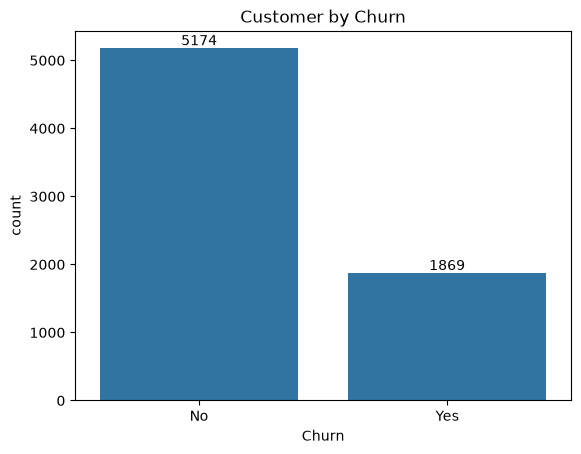

In [13]:
ax = sns.countplot(x = df["Churn"])
ax.bar_label(ax.containers[0])
plt.title('Customer by Churn')
plt.show()

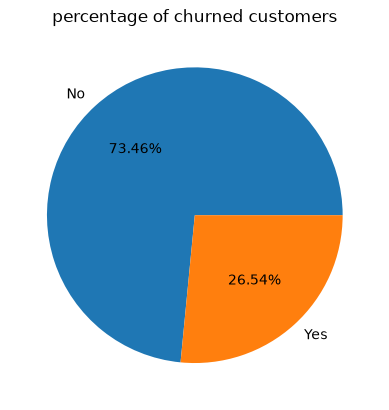

In [14]:
gb = df.groupby('Churn').agg({'Churn':"count"})
plt.pie(gb['Churn'],labels=gb.index, autopct = '%1.2f%%')
plt.title('percentage of churned customers')
plt.show()


# From the given pie chart we can conclude that 26.54% of our customers have churned out 
#Now let's explore the reason behind it

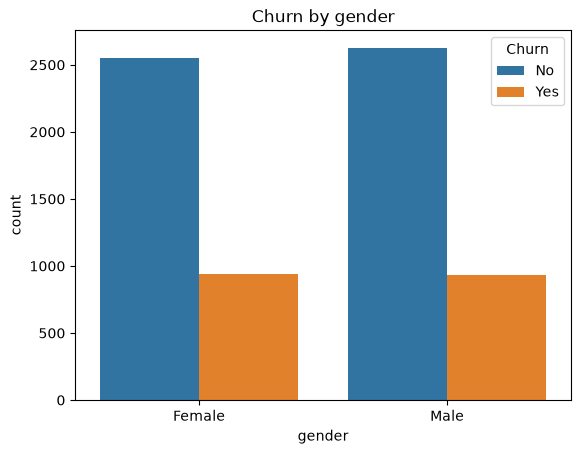

In [18]:
sns.countplot(x = 'gender', data = df, hue = 'Churn')
plt.title('Churn by gender')
plt.show()

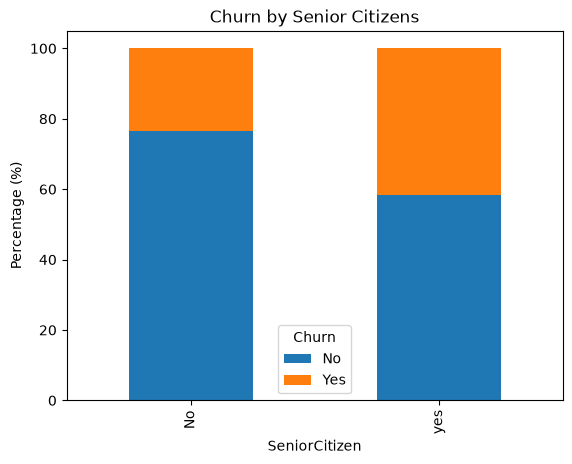

In [26]:
total_counts = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize = True).unstack()*100
total_counts.plot(kind = 'bar', stacked = True)
#sns.countplot(x = 'SeniorCitizen', data = df, hue = 'Churn')
plt.title('Churn by Senior Citizens')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage (%)')
plt.show()

#comparative a greater percentage of people in senior citizen category have churned

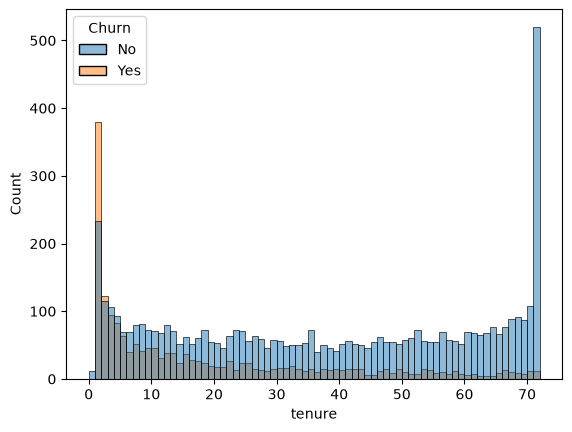

In [27]:
sns.histplot(x ='tenure',data = df, bins = 72, hue = 'Churn')
plt.show()

# people who  have used our services for a long time have stayed and people who have used used our services for 1 or 2 months have churned 

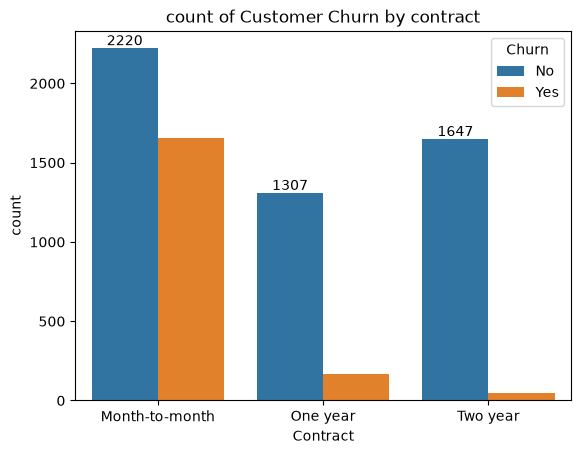

In [33]:
ax = sns.countplot(x = 'Contract',data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
plt.title('count of Customer Churn by contract')
plt.show()

#people who have month to month contract have likely to churn than from those who have 1 or 2 years or contract 

In [34]:
df.columns.values

<ArrowStringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

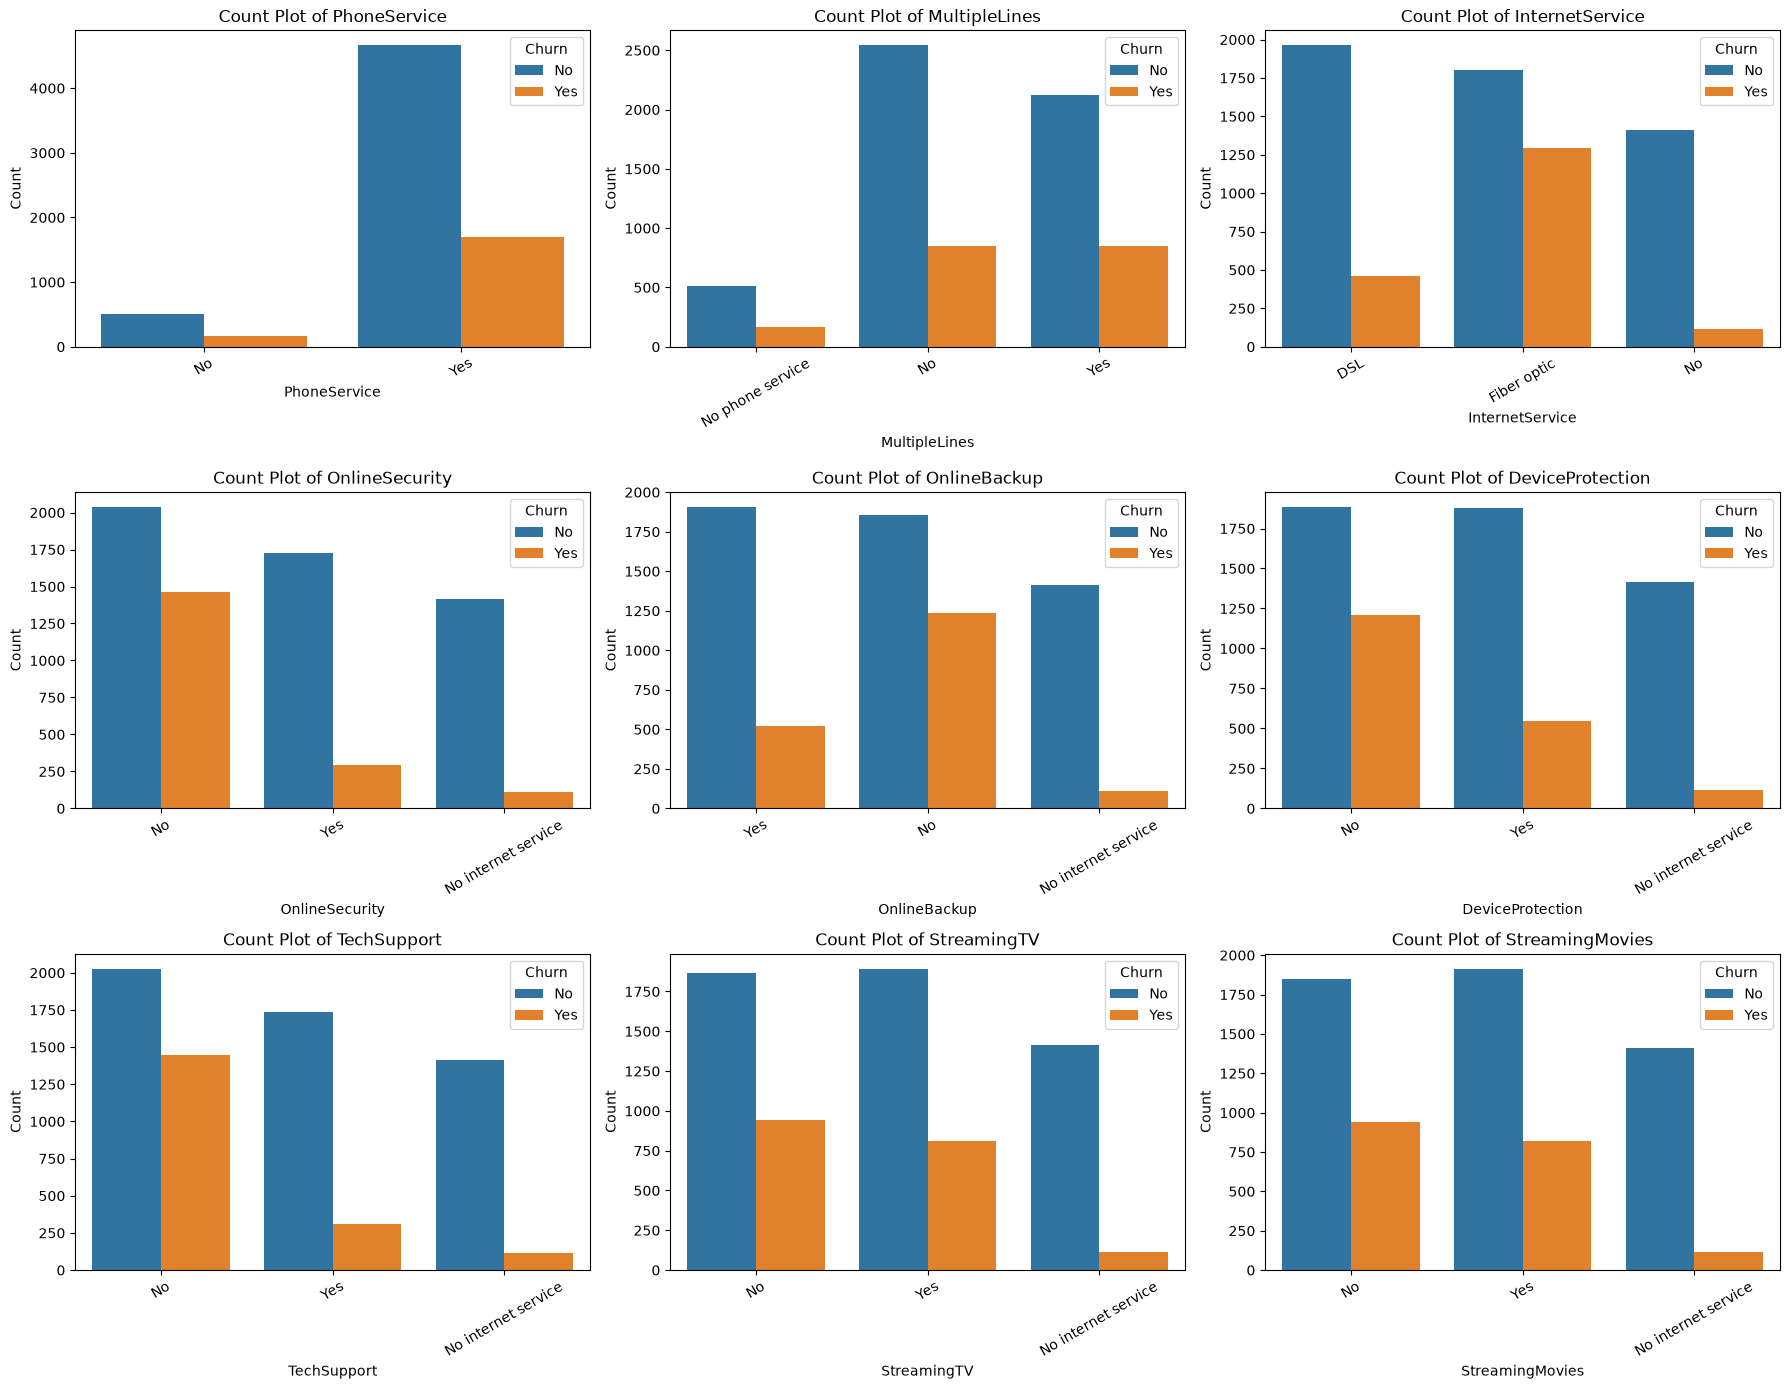

In [40]:
columns = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for ax, col in zip(axes.flatten(), columns):
    sns.countplot(data=df, x=col, ax=ax,hue = 'Churn')
    ax.set_title(f'Count Plot of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#Customers without OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport show relatively higher churn compared with those who have these services.
#Fiber optic internet users have noticeably higher churn, while DSL users show comparatively lower churn.
#Overall, customers lacking additional services and using fiber optic internet appear more likely to churn.

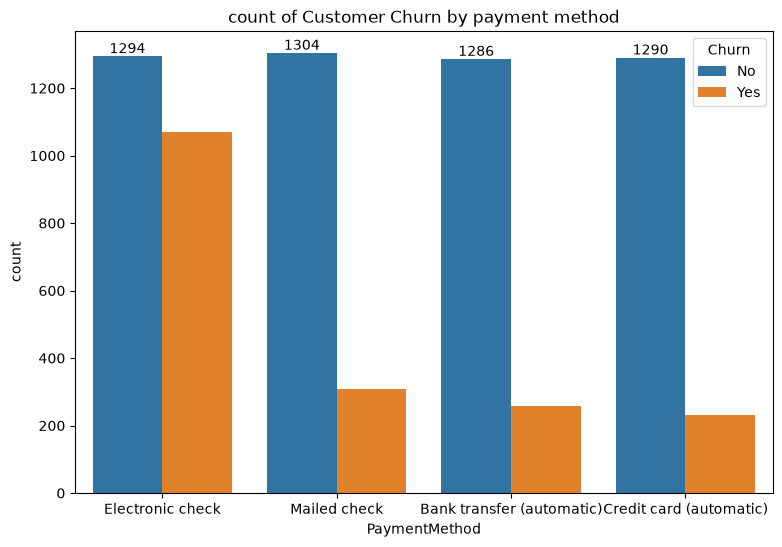

In [43]:
plt.figure(figsize = (9,6))
ax = sns.countplot(x = 'PaymentMethod',data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
plt.title('count of Customer Churn by payment method')
plt.show()

# customer is likely to churn when he is using electronic check as a payment method